# Assignment 2: Applying ML Algorithms
* **Student Name:** Mohammed Al-masawabi
* **Student ID:** 1320222450
* **Instructor:** Ibrahim O. I. Kaware


###  Library Imports & Setup
Importing essential libraries for data manipulation, analysis, visualization, and machine learning model implementation.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, classification_report, confusion_matrix
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA



## 1. Data Preprocessing (Review & Extension)

In this section, we load the dataset, handle missing values, engineer new features, and encode categorical variables manually to ensure full transparency of the data transformation process.

###  Data Loading & Initial Inspection
Loading the dataset and performing initial exploratory analysis to verify data dimensions and identify missing values, which is the foundational step for data cleaning.

In [4]:
# Load data with the correct delimiter based on the dataset
df = pd.read_csv('marketing_campaign.csv', sep=';')
print('Shape:', df.shape )

# Display first 5 rows
display(df.head())

# Check for missing values
print("Missing values per column:\n", df.isnull().sum())

Shape: (2240, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


Missing values per column:
 ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64


###  Data Preprocessing & Feature Engineering
Cleaning the dataset and constructing new features for modeling. This includes median imputation for missing income, engineering behavioral attributes, outlier removal, and categorical encoding.

In [5]:
# Handle missing values in Income (median imputation)
df['Income'] = df['Income'].fillna(df['Income'].median())

# Feature Engineering
# Create Age
df['Age'] = 2026 - df['Year_Birth']

# Create TotalSpending
spend_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df['TotalSpending'] = df[spend_cols].sum(axis=1)

# Create TotalChildren
df['TotalChildren'] = df['Kidhome'] + df['Teenhome']

# Filtering
df = df[(df['Age'] >= 18) & (df['Age'] <= 100) & (df['Income'] > 0)]

# Encoding
edu_map = {"Basic": 0, "2n Cycle": 1, "Graduation": 1, "Master": 2, "PhD": 3}
df['Education'] = df['Education'].map(edu_map)

# One-hot encode Marital_Status (top 4, rest 'Other')
top_4_marital = df['Marital_Status'].value_counts().index[:4]
df['Marital_Status'] = df['Marital_Status'].apply(lambda x: x if x in top_4_marital else 'Other')
df = pd.get_dummies(df, columns=['Marital_Status'], drop_first=True)

# Drop columns to prevent data leakage and remove redundant IDs
df.drop(['ID', 'Year_Birth', 'Dt_Customer', 'Z_CostContact', 'Z_Revenue'] + spend_cols, axis=1, inplace=True, errors='ignore')


display(df.head())
print('Shape:', df.shape )


,Education,Income,Kidhome,Teenhome,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,...,AcceptedCmp2,Complain,Response,Age,TotalSpending,TotalChildren,Marital_Status_Married,Marital_Status_Other,Marital_Status_Single,Marital_Status_Together
0,1,58138.0,0,0,58,3,8,10,4,7,...,0,0,1,69,1617,0,False,False,True,False
1,1,46344.0,1,1,38,2,1,1,2,5,...,0,0,0,72,27,2,False,False,True,False
2,1,71613.0,0,0,26,1,8,2,10,4,...,0,0,0,61,776,0,False,False,False,True
3,1,26646.0,1,0,26,2,2,0,4,6,...,0,0,0,42,53,1,False,False,False,True
4,3,58293.0,1,0,94,5,5,3,6,5,...,0,0,0,45,422,1,True,False,False,False


Shape: (2237, 24)


### 2. Supervised Learning: Regression
**Goal:** Predict the continuous target variable **TotalSpending**.
# The dataset is split into an 80/20 train-test ratio. Features are standardized using **StandardScaler** to ensure scale uniformity. Three regression algorithms (Linear Regression, Ridge Regression, and Decision Tree) are implemented and evaluated using MSE, RMSE, and $R^2$ Score.

### 💡 Why Ridge Regression?
* **Handles Multicollinearity:** Marketing features (like Income and Purchases) are highly correlated. Ridge stabilizes the model coefficients.
* **Prevents Overfitting:** It applies **L2 Regularization** to penalize large weights, ensuring the model generalizes better on unseen test data.

In [6]:
# Target Variable
X_reg = df.drop(['TotalSpending'], axis=1)
y_reg = df['TotalSpending']

# Train/Test Split (80/20)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Feature Scaling
scaler_reg = StandardScaler()
X_train_r_scaled = scaler_reg.fit_transform(X_train_r)
X_test_r_scaled = scaler_reg.transform(X_test_r)

# Models to Implement
models_reg = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(max_depth=5)
}

# Evaluation
results_reg = []
for name, model in models_reg.items():
    model.fit(X_train_r_scaled, y_train_r)
    y_pred = model.predict(X_test_r_scaled)

    mse = mean_squared_error(y_test_r, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_r, y_pred)

    results_reg.append({"Model": name, "MSE": mse, "RMSE": rmse, "R2 Score": r2})

display(pd.DataFrame(results_reg))

,Model,MSE,RMSE,R2 Score
0,Linear Regression,70531.267216,265.577234,0.814330
1,Ridge Regression,70520.741910,265.557417,0.814358
2,Decision Tree,59744.715910,244.427322,0.842725


### 3. Supervised Learning: Classification
**Goal:** Predict binary target variable **Response** (whether a customer accepted the campaign).
- Inspects class distribution to identify potential imbalance.
- Splits data (80/20) and standardizes features for distance/gradient-sensitive models.
- Trains Logistic Regression (with balanced class weights), K-Nearest Neighbors (KNN), and Random Forest.
- Evaluates using **classification_report** and visualizes performance via a **confusion_matrix**.

Class Distribution:
 Response
0    0.850693
1    0.149307
Name: proportion, dtype: float64

--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.95      0.81      0.87       376
           1       0.43      0.76      0.55        72

    accuracy                           0.80       448
   macro avg       0.69      0.79      0.71       448
weighted avg       0.86      0.80      0.82       448



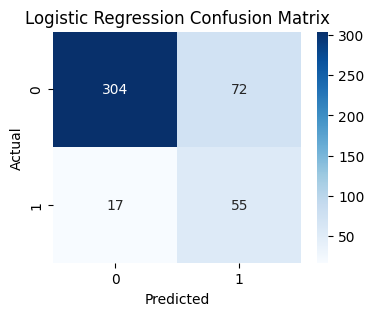


--- KNN ---
              precision    recall  f1-score   support

           0       0.89      0.97      0.93       376
           1       0.72      0.40      0.52        72

    accuracy                           0.88       448
   macro avg       0.81      0.69      0.72       448
weighted avg       0.87      0.88      0.86       448



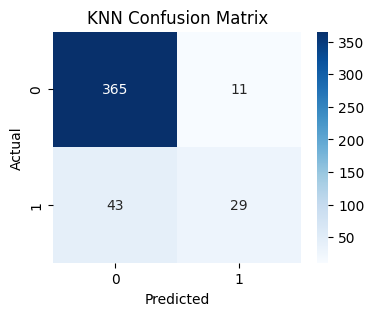


--- Random Forest ---
              precision    recall  f1-score   support

           0       0.91      0.97      0.94       376
           1       0.74      0.47      0.58        72

    accuracy                           0.89       448
   macro avg       0.82      0.72      0.76       448
weighted avg       0.88      0.89      0.88       448



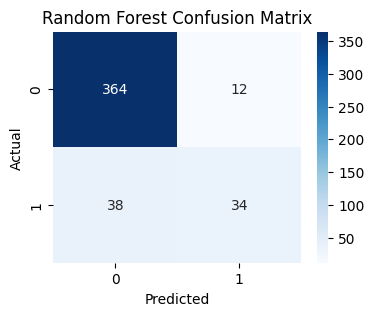

In [7]:
# Target Variable: Response
X_clf = df.drop(['Response'], axis=1)
y_clf = df['Response']

# Show class distribution
print("Class Distribution:\n", y_clf.value_counts(normalize=True))

# Train/Test Split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

# Feature Scaling
scaler_clf = StandardScaler()
X_train_c_scaled = scaler_clf.fit_transform(X_train_c)
X_test_c_scaled = scaler_clf.transform(X_test_c)

# Models
models_clf = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# Training & Evaluation
for name, model in models_clf.items():
    # Random Forest doesn't need scaled data
    if name == "Random Forest":
        model.fit(X_train_c, y_train_c)
        y_pred = model.predict(X_test_c)
    else:
        model.fit(X_train_c_scaled, y_train_c)
        y_pred = model.predict(X_test_c_scaled)

    print(f"\n--- {name} ---")
    print(classification_report(y_test_c, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test_c, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} Confusion Matrix")
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

### 4. Unsupervised Learning: Elbow Method for Optimal Clusters
- **Feature Selection:** Extracts core features (**TotalSpending**, **Income**, **Age**, **TotalChildren**) for customer segmentation.
- **Scaling:** Normalizes attributes using **StandardScaler** to prevent feature dominance in distance calculations.
- **Optimization:** Runs the Elbow Method by tracking **Inertia** across a range of $k$ values (1 to 10) to determine the ideal number of clusters.

###  Clustering Strategy (Elbow & PCA)
* **Elbow Method:** Used to find the optimal number of clusters (**k=3**) by locating the "bend" where adding more clusters gives diminishing returns in reducing inertia.
* **PCA (Dimensionality Reduction):** Since we have 4 features, we compressed them into 2 principal components **strictly for 2D visualization** purposes.

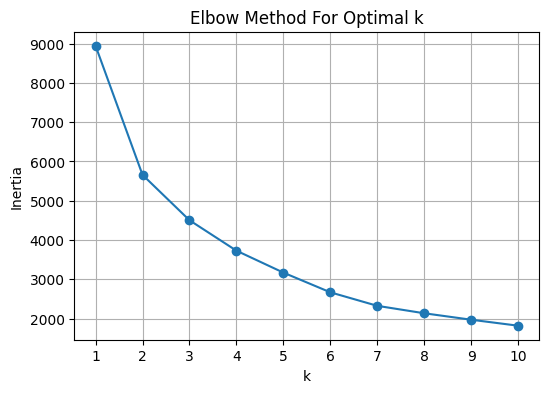

In [8]:
# Data Preparation
cluster_cols = ['TotalSpending', 'Income', 'Age', 'TotalChildren']
X_cluster = df[cluster_cols]

# Scaling
scaler_clust = StandardScaler()
X_cluster_scaled = scaler_clust.fit_transform(X_cluster)

# Elbow Method (Inertia vs k from 1 to 10)
inertia = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, inertia, marker='o')
plt.title('Elbow Method For Optimal k')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.xticks(K_range)
plt.grid(True)
plt.show()

### K-Means Clustering, PCA Visualization & Profiling
- **Model Fitting:** Applies K-Means with the optimal number of clusters ($k=3$) to segment customers.
- **Dimensionality Reduction:** Uses Principal Component Analysis (PCA) to project the 4D feature space into 2D for visual interpretation.
- **Customer Profiling:** Aggregates the original features by cluster using the mean to interpret and identify the business characteristics of each segment.

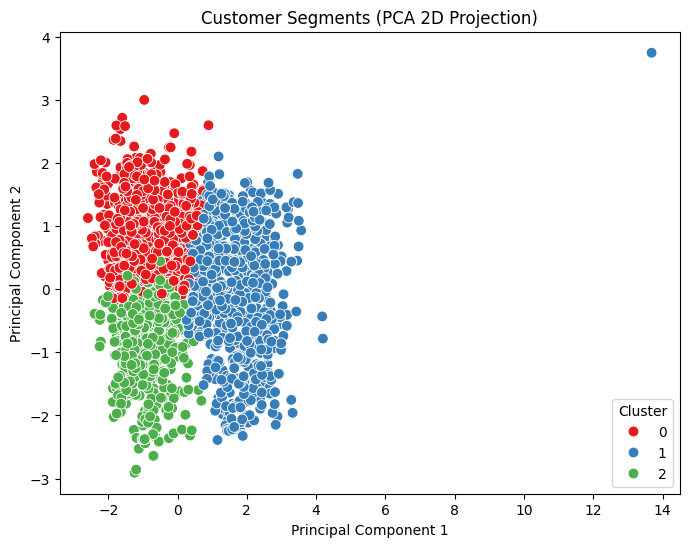

,TotalSpending,Income,Age,TotalChildren
Cluster,,,,
0,298.55,47278.93,63.94,1.69
1,1289.28,74150.17,58.64,0.39
2,159.80,33161.61,48.77,0.84


In [9]:
# Fit K-Means with chosen k (Assuming k=3 based on a typical elbow curve for this data)
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_cluster_scaled)

# Visualization (PCA reduction to 2 components)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['Cluster'], palette='Set1', s=60)
plt.title('Customer Segments (PCA 2D Projection)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()

# Cluster Profiling
cluster_profiles = df.groupby('Cluster')[cluster_cols].mean().round(2)
display(cluster_profiles)